# Performance Testing

- general statistical methods for evaluation
- downstream task: train two models and use real data as validation set

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance

In [2]:
real = pd.read_csv("../datasets/filtered.csv", engine="pyarrow")
# synth = pd.read_csv("../output/without-dp.csv", engine="pyarrow")
synth_dp = pd.read_csv("../output/dp56.csv", engine="pyarrow")
# # before = pd.read_csv("../output/before-calib.csv", engine="pyarrow")
# after = pd.read_csv("../output/after-calib.csv", engine="pyarrow")

In [3]:
synth_dp['encrypt_data'] = synth_dp['encrypt_data'].astype(int)
# synth['encrypt_data'] = synth['encrypt_data'].astype(int)
real['encrypt_data'] = real['encrypt_data'].astype(int)

In [4]:
real['sync'] = (real['st_files_skipped'] > 0).astype(int)

In [5]:
numeric_cols = real.select_dtypes(include=np.number).columns.intersection(
    real.select_dtypes(include=np.number).columns
)

selected_cols = [
    "sync",
    "encrypt_data",
    "st_files",
    "st_dirs",
    "st_successful",
    "st_failed",
    "st_expired",
    "st_canceled",
    "st_bytes_xfered",
    "st_faults",
    "st_files_skipped",
    "st_xfer_time_ms"
]


# Ensure both datasets contain these columns
real = real[selected_cols].dropna()
# synth = synth[selected_cols].dropna()
synth_dp = synth_dp[selected_cols].dropna()
# after = after[selected_cols].dropna()
# before = before[selected_cols].dropna()

print(f"Validating {len(selected_cols)} transfer-related features.\n")

Validating 12 transfer-related features.



### Descriptive Statistics

In [5]:
stats_cols = ['mean', 'std', 'min', 'max']
quantile_levels = [0.0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]

# Descriptive stats table
stats_real = real.describe().T[stats_cols]
stats_synth = synth.describe().T[stats_cols]

stats_table = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1,
)

# Quantiles table
real_q = real.quantile(quantile_levels).T
synth_q = synth.quantile(quantile_levels).T
real_q = real_q.rename(columns={q: f"q{q:g}" for q in quantile_levels})
synth_q = synth_q.rename(columns={q: f"q{q:g}" for q in quantile_levels})

quantile_table = pd.concat(
    [real_q.add_suffix('_real'), synth_q.add_suffix('_synth')],
    axis=1,
)

stats_table, quantile_table


(                      mean_real      std_real  min_real      max_real  \
 st_files           5.709089e+03  3.687395e+05       0.0  5.074214e+08   
 st_dirs            3.165675e+02  3.371757e+04       0.0  8.791225e+07   
 st_successful      4.519742e+03  2.529234e+05       0.0  5.114859e+08   
 st_failed          4.972352e+01  5.160599e+04       0.0  1.440816e+08   
 st_expired         5.304780e+02  1.934975e+05       0.0  4.457491e+08   
 st_canceled        9.686416e+02  1.760280e+05       0.0  2.807579e+08   
 st_bytes_xfered    5.600996e+10  2.698348e+12       0.0  7.802815e+15   
 st_faults          5.122567e+00  7.664199e+01       0.0  1.182540e+05   
 st_files_skipped   2.466020e+03  1.467027e+05       0.0  2.428073e+08   
 st_skipped_errors  1.249673e+00  4.867392e+03       0.0  3.124745e+07   
 st_xfer_time_ms    8.983515e+05  1.889429e+07       0.0  1.482032e+10   
 
                      mean_synth     std_synth  min_synth     max_synth  
 st_files           1.666162e+06  6.

In [17]:
def sigma_filter(df, column: str, k: float = 3.0):
    mu = df[column].mean()
    sigma = df[column].std()
    lower, upper = mu - k * sigma, mu + k * sigma
    return df[(df[column] >= lower) & (df[column] <= upper)]

k = 2  # number of sigmas
real_filtered = sigma_filter(real, "st_bytes_xfered", k=k)
synth_filtered = sigma_filter(synth, "st_bytes_xfered", k=k)
real_filtered = sigma_filter(real, "st_xfer_time_ms", k=k)
synth_filtered = sigma_filter(synth, "st_xfer_time_ms", k=k)

In [ ]:
import numpy as np
import pandas as pd

qs = [0.999, 0.9999, 0.99999, 0.999999]
q_labels = [f"q{str(q).replace('.', '')}" for q in qs]

def quant_matrix(df):
    q = df[selected_cols].quantile(qs).T
    q.columns = q_labels
    return q

q_real = quant_matrix(real)
q_before = quant_matrix(before)
q_after = quant_matrix(after)

ratio_before = (q_before / q_real).add_prefix("before_")
ratio_after = (q_after / q_real).add_prefix("after_")

# ratio_table = pd.concat([ratio_before, ratio_after], axis=1)
ratio_table = ratio_after.reset_index().rename(columns={"index": "feature"})
# Assuming ratio_table from earlier
# ratio_table columns: feature, before_q0999, ..., after_q0999999

\begin{table}
\caption{Tail inflation ratios}
\label{tab:tail_ratio}
\begin{tabular}{lrrrr}
\toprule
feature & after\_q0999 & after\_q09999 & after\_q099999 & after\_q0999999 \\
\midrule
st\_files & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.62e+01 \\
st\_dirs & 2.01e-01 & 1.02e-01 & 5.43e-02 & 2.08e-02 \\
st\_successful & 1.00e+00 & 1.00e+00 & 1.00e+00 & 2.16e+01 \\
st\_failed & NaN & 1.03e+00 & 1.00e+00 & 7.15e-02 \\
st\_expired & 1.00e+00 & 1.00e+00 & 1.00e+00 & 4.02e-01 \\
st\_canceled & 1.00e+00 & 1.00e+00 & 1.00e+00 & 5.22e-01 \\
st\_bytes\_xfered & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.87e+00 \\
st\_faults & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.11e+00 \\
st\_files\_skipped & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.64e+00 \\
st\_skipped\_errors & 1.00e+00 & 1.00e+00 & 1.00e+00 & 2.95e+00 \\
st\_xfer\_time\_ms & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.47e+01 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
for col in selected_cols:
    print(col, "real", np.quantile(real[col], [0.0, 0.25, 0.999, 0.9999, 0.99999, 0.999999]))
    print(col, "before", np.quantile(before[col], [0.999, 0.9999, 0.99999, 0.999999]))
    print(col, "after", np.quantile(after[col], [0.999, 0.9999, 0.99999, 0.999999]))

st_files real [6.63200193e+05 8.05169512e+06 3.51499332e+07 1.63297968e+08]
st_files before [1.50045749e+05 1.10261710e+07 8.73716460e+08 6.55724885e+10]
st_files after [6.63196274e+05 8.05169500e+06 3.51606530e+07 2.63800523e+09]
st_dirs real [   37623.           327856.          1829212.34105936 14688348.3897391 ]
st_dirs before [  30.        108.        343.       1060.236664]
st_dirs after [  7579.          33519.          99347.22612973 304916.50410249]
st_successful real [  530085.          5148515.         20598637.93179131 81097794.11523601]
st_successful before [2.95835579e+05 2.81290436e+07 2.66722278e+09 2.26626109e+11]
st_successful after [5.30078216e+05 5.14708647e+06 2.05986380e+07 1.75020594e+09]
st_failed real [0.00000000e+00 1.90000000e+01 2.09082934e+05 1.13207527e+07]
st_failed before [0. 1. 1. 6.]
st_failed after [0.00000000e+00 1.94861000e+01 2.09001081e+05 8.09683824e+05]
st_expired real [1.15800000e+03 4.08717000e+05 8.49738315e+06 7.03001804e+07]
st_expired befo

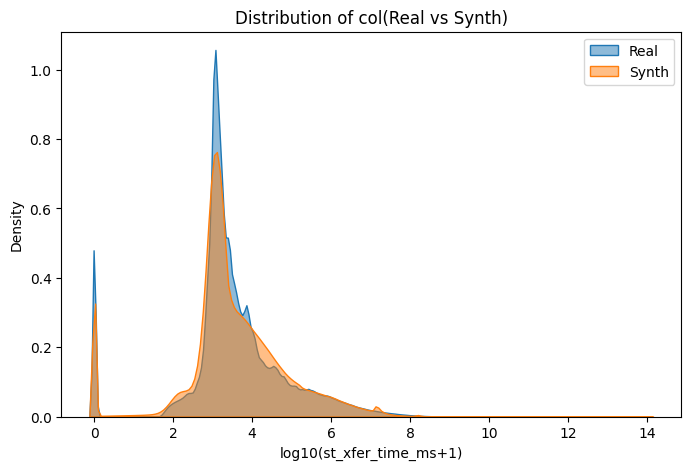

In [6]:
# Plot the distributions
col = "st_xfer_time_ms"
plt.figure(figsize=(8, 5))

real_log = np.log10(real[col].clip(lower=1))
synth_log = np.log10(after[col].clip(lower=1))

sns.kdeplot(real_log, label="Real", fill=True, alpha=0.5)
sns.kdeplot(synth_log, label="Synth", fill=True, alpha=0.5)
plt.title("Distribution of col(Real vs Synth)")
plt.xlabel(f'log10({col}+1)')
plt.ylabel("Density")
plt.legend()
plt.show()


In [6]:
ks_results, wd_results = {}, {}
pd.set_option("display.precision", 12)
for col in selected_cols:
    ks = ks_2samp(real[col], synth_dp[col]).statistic
    wd = wasserstein_distance(real[col], synth_dp[col])
    ks_results[col] = ks
    wd_results[col] = wd

ks_df = pd.DataFrame({'KS_stat': ks_results, 'Wasserstein': wd_results})
print("\nDistribution similarity (lower is better):")
print(ks_df.sort_values("KS_stat"))



Distribution similarity (lower is better):
                         KS_stat         Wasserstein
st_failed         0.000207445206  4.972351581624e+01
encrypt_data      0.006800258442  6.800258441902e-03
st_expired        0.010628708134  5.304780191998e+02
st_canceled       0.019199043611  9.686371023335e+02
st_faults         0.032976359559  5.063584875183e+00
st_xfer_time_ms   0.034114104690  5.075141955520e+05
sync              0.037816045012  3.781604501152e-02
st_successful     0.062478759151  7.306348740512e+03
st_files          0.069516355035  5.357862806048e+03
st_files_skipped  0.070532040277  2.464612446707e+03
st_dirs           0.071642354319  3.161225626784e+02
st_bytes_xfered   0.086222753762  4.197796403145e+10


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
# Define column names as variables
target_col = 'st_xfer_time_ms'

feature_combinations = [
    ['st_bytes_xfered'],
    ['st_bytes_xfered', 'sync'],
    ['st_bytes_xfered', 'sync', 'st_files'],
    ['st_bytes_xfered', 'sync', 'st_files', 'st_dirs'],
    ['st_bytes_xfered', 'encrypt_data'],
    ['st_bytes_xfered', 'encrypt_data', 'st_files'],
    ['st_bytes_xfered', 'encrypt_data', 'st_files', 'st_dirs'],
    ['st_bytes_xfered', 'sync', 'st_files', 'st_dirs', 'encrypt_data',]
    #['st_bytes_xfered', 'st_files'],
    #['st_bytes_xfered', 'st_files', 'st_dirs'],
    #['st_bytes_xfered', 'encrypt_data'],
    #['st_bytes_xfered', 'st_files', 'encrypt_data'],
    #['st_bytes_xfered', 'st_files', 'st_dirs', 'encrypt_data'],
    #['st_bytes_xfered', 'grp_delete'],
    #['st_bytes_xfered', 'st_files', 'grp_delete'],
    #['st_bytes_xfered', 'st_files', 'st_dirs', 'grp_delete'],
    #['st_bytes_xfered', 'encrypt_data', 'grp_delete'],
    #['st_bytes_xfered', 'st_files', 'encrypt_data', 'grp_delete'],
    #['st_bytes_xfered', 'st_files', 'st_dirs', 'encrypt_data', 'grp_delete'],
    # Add more combinations as needed
]

# Iterate over each combination
for feature_cols in feature_combinations:
    
    display_feature_cols = feature_cols.copy()

    # Prepare data
    X = real[feature_cols]
    y = np.log10(real[target_col] + 1)
    X_syn = synth_dp[feature_cols]
    y_syn = np.log10(synth_dp[target_col] + 1)
    
    if 'st_files_skipped' in feature_cols:
        X.loc[:, 'st_files_skipped'] = (X['st_files_skipped'] > 0).astype(int)
        X_syn.loc[:, 'st_files_skipped'] = (X_syn['st_files_skipped'] > 0).astype(int)
        idx = display_feature_cols.index('st_files_skipped')
        display_feature_cols[idx] = 'sync'
  
    print(f"\n{'='*80}")
    print(f"Features: {display_feature_cols}")
    print(f"{'='*80}")    
    
    # Split and train
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model.fit(X_train, y_train)
    
    r_pred_log = model.predict(X_test)
    
    # Calculate metrics on LOG scale
    real_mse_log = mean_squared_error(y_test, r_pred_log)
    real_rmse_log = np.sqrt(real_mse_log)
    real_mae_log = mean_absolute_error(y_test, r_pred_log)
    real_mape_log = mean_absolute_percentage_error(y_test, r_pred_log)
    real_r2_log = r2_score(y_test, r_pred_log)
    
    # Convert back to original scale
    y_test_original = 10**y_test
    r_pred_original = 10**r_pred_log
    
    # Calculate metrics on ORIGINAL scale
    real_mse = mean_squared_error(y_test_original, r_pred_original)
    real_rmse = np.sqrt(real_mse)
    real_mae = mean_absolute_error(y_test_original, r_pred_original)
    real_mape = mean_absolute_percentage_error(y_test_original, r_pred_original)
    real_r2 = r2_score(y_test_original, r_pred_original)
    
    # Predict on synthetic data (in log scale)
    s_pred_log = model.predict(X_syn)
    
    # Calculate metrics on LOG scale
    syn_mse_log = mean_squared_error(y_syn, s_pred_log)
    syn_rmse_log = np.sqrt(syn_mse_log)
    syn_mae_log = mean_absolute_error(y_syn, s_pred_log)
    syn_mape_log = mean_absolute_percentage_error(y_syn, s_pred_log)
    syn_r2_log = r2_score(y_syn, s_pred_log)
    
    # Convert back to original scale
    y_syn_original = 10**y_syn
    s_pred_original = 10**s_pred_log
    
    # Calculate metrics on ORIGINAL scale
    syn_mse = mean_squared_error(y_syn_original, s_pred_original)
    syn_rmse = np.sqrt(syn_mse)
    syn_mae = mean_absolute_error(y_syn_original, s_pred_original)
    syn_mape = mean_absolute_percentage_error(y_syn_original, s_pred_original)
    syn_r2 = r2_score(y_syn_original, s_pred_original)
    
    # Calculate deltas for LOG scale
    delta_mse_log = syn_mse_log - real_mse_log
    delta_rmse_log = syn_rmse_log - real_rmse_log
    delta_mae_log = syn_mae_log - real_mae_log
    delta_mape_log = syn_mape_log - real_mape_log
    delta_r2_log = syn_r2_log - real_r2_log
    
    # Calculate deltas for ORIGINAL scale
    delta_mse = syn_mse - real_mse
    delta_rmse = syn_rmse - real_rmse
    delta_mae = syn_mae - real_mae
    delta_mape = syn_mape - real_mape
    delta_r2 = syn_r2 - real_r2
    
    # Print results - LOG SCALE
    print(f"\n--- METRICS ON LOG10 SCALE ---")
    print(f'Mean Squared Error:      Real: {real_mse_log:.4f}  |  Syn: {syn_mse_log:.4f}  |  Delta: {delta_mse_log:.4f}')
    print(f'Root Mean Squared Error: Real: {real_rmse_log:.4f}  |  Syn: {syn_rmse_log:.4f}  |  Delta: {delta_rmse_log:.4f}')
    print(f'Mean Absolute Error:     Real: {real_mae_log:.4f}  |  Syn: {syn_mae_log:.4f}  |  Delta: {delta_mae_log:.4f}')
    print(f'Mean Absolute % Error:   Real: {real_mape_log:.4f}  |  Syn: {syn_mape_log:.4f}  |  Delta: {delta_mape_log:.4f}')
    print(f'R² Score:                Real: {real_r2_log:.4f}  |  Syn: {syn_r2_log:.4f}  |  Delta: {delta_r2_log:.4f}')
    
    # Print results - ORIGINAL SCALE
    print(f"\n--- METRICS ON ORIGINAL SCALE (milliseconds) ---")
    print(f'Mean Squared Error:      Real: {real_mse:.4f}  |  Syn: {syn_mse:.4f}  |  Delta: {delta_mse:.4f}')
    print(f'Root Mean Squared Error: Real: {real_rmse:.4f}  |  Syn: {syn_rmse:.4f}  |  Delta: {delta_rmse:.4f}')
    print(f'Mean Absolute Error:     Real: {real_mae:.4f}  |  Syn: {syn_mae:.4f}  |  Delta: {delta_mae:.4f}')
    print(f'Mean Absolute % Error:   Real: {real_mape:.4f}  |  Syn: {syn_mape:.4f}  |  Delta: {delta_mape:.4f}')
    print(f'R² Score:                Real: {real_r2:.4f}  |  Syn: {syn_r2:.4f}  |  Delta: {delta_r2:.4f}')


Features: ['st_bytes_xfered']

--- METRICS ON LOG10 SCALE ---
Mean Squared Error:      Real: 0.6317  |  Syn: 0.5678  |  Delta: -0.0639
Root Mean Squared Error: Real: 0.7948  |  Syn: 0.7535  |  Delta: -0.0413
Mean Absolute Error:     Real: 0.5256  |  Syn: 0.5337  |  Delta: 0.0082
Mean Absolute % Error:   Real: 458420145470726.3125  |  Syn: 140286399664742.5938  |  Delta: -318133745805983.7500
R² Score:                Real: 0.6262  |  Syn: 0.5935  |  Delta: -0.0327

--- METRICS ON ORIGINAL SCALE (milliseconds) ---
Mean Squared Error:      Real: 348148821219698.0625  |  Syn: 1737748341411022.7500  |  Delta: 1389599520191324.7500
Root Mean Squared Error: Real: 18658746.5072  |  Syn: 41686308.8005  |  Delta: 23027562.2933
Mean Absolute Error:     Real: 825958.1314  |  Syn: 775795.3543  |  Delta: -50162.7771
Mean Absolute % Error:   Real: 6.7805  |  Syn: 5.6180  |  Delta: -1.1625
R² Score:                Real: 0.0421  |  Syn: 0.0112  |  Delta: -0.0308

Features: ['st_bytes_xfered', 'sync']
